### Simulation Info
For the updated parameters:  
Column 1: wavelength (µm)  
Column 2: pitch-to-wavelength ratio (unitless), chosen so that (Column 2) × (Column 1) = 0.4 µm (fixed physical pitch)  
Column 3: substrate dielectric constant, ε_sub  
Column 4: meta-atom dielectric constant, ε_atom  
Here ε = n² for both materials.  


Available datasets: ['neff', 'params', 'pattern', 'weight']

### Importing and Loading dataset

In [14]:
from typing import Dict, Tuple
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import MNIST
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np

%matplotlib inline

from torch import autograd
from torch.autograd import Variable
from tensorboardX import SummaryWriter
import torch.optim as optim

In [15]:
import h5py
import matplotlib.pyplot as plt

# Load the file
file_path = "CollectData_expanded2.h5"
with h5py.File(file_path, "r") as f:
    # Inspect keys
    print("Available datasets:", list(f.keys()))
    

Available datasets: ['neff', 'params', 'pattern', 'weight']


### Plotting Dataset

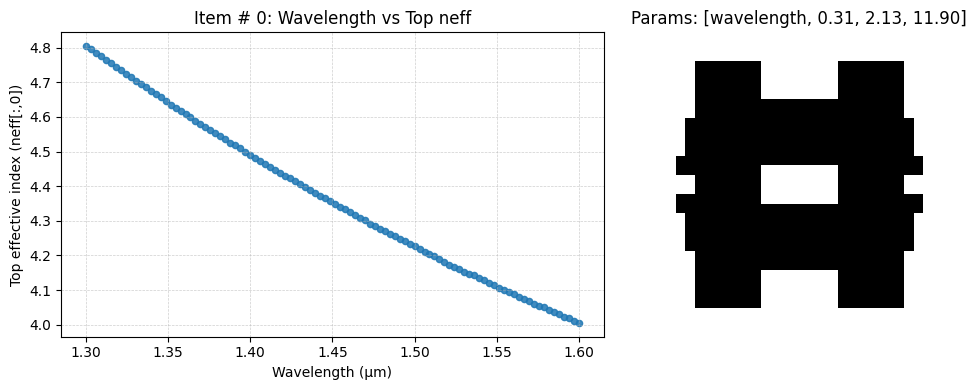

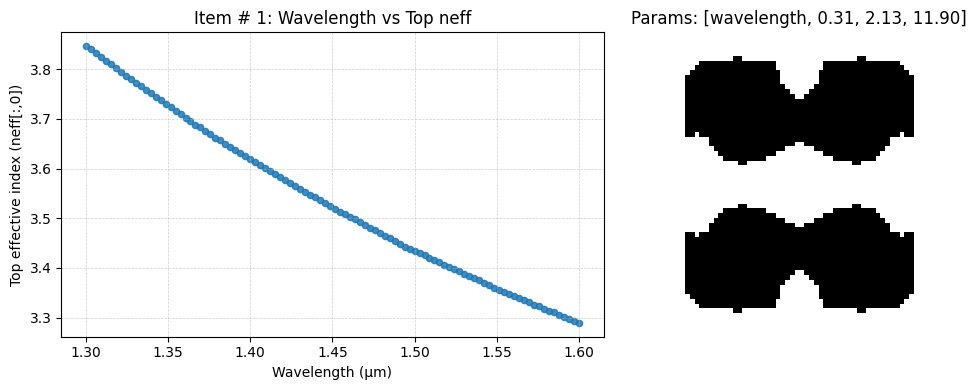

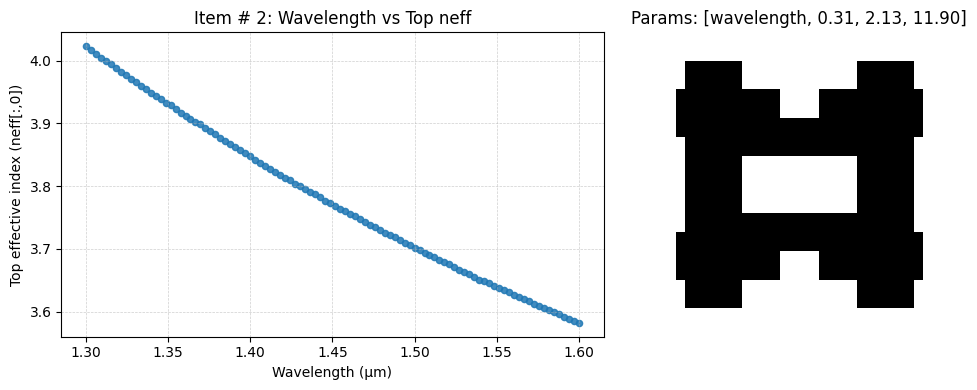

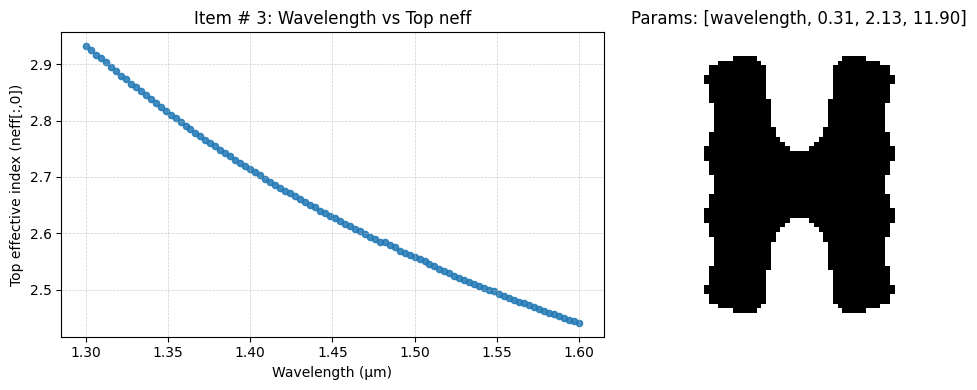

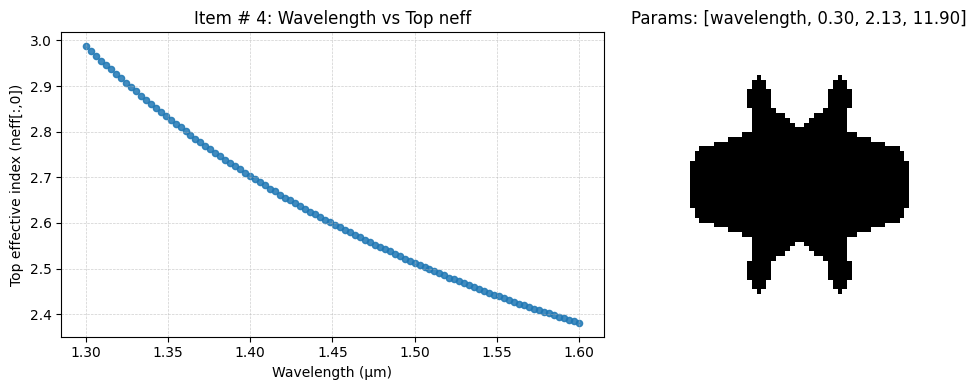

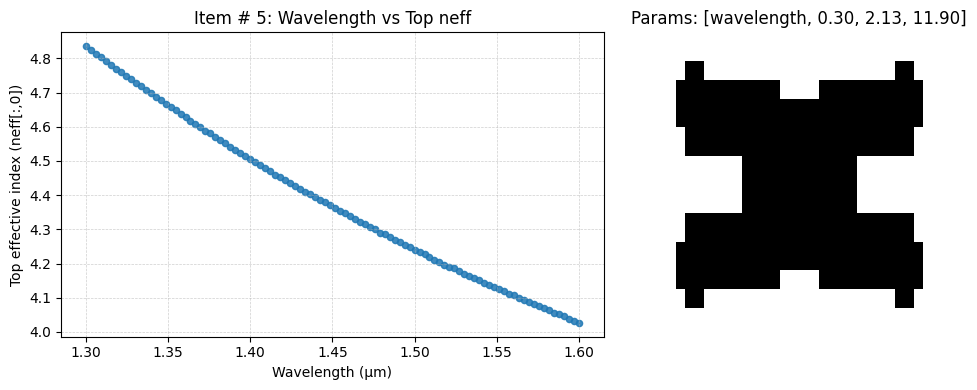

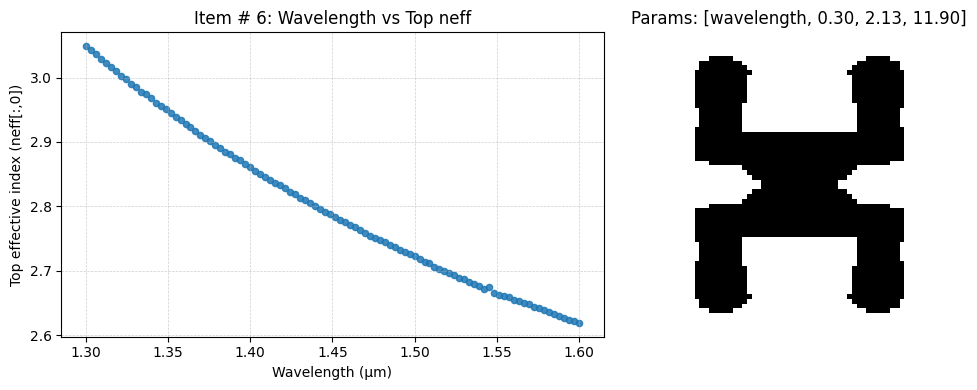

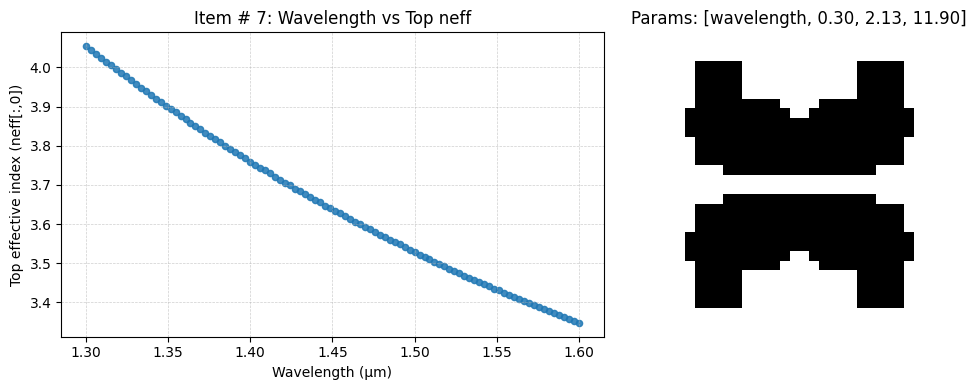

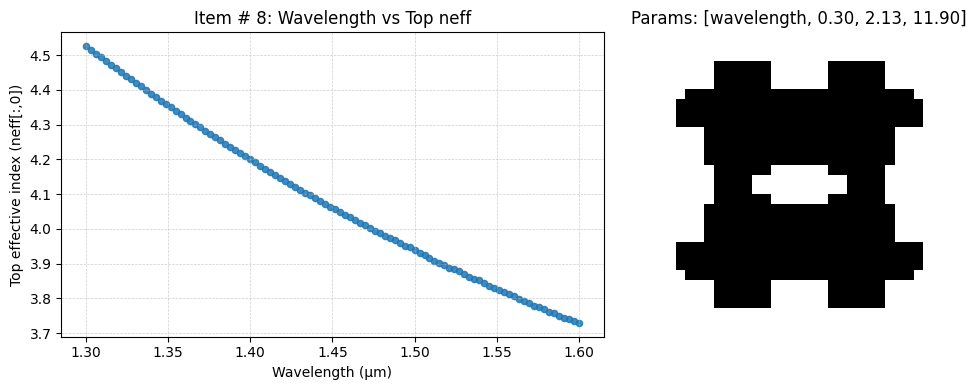

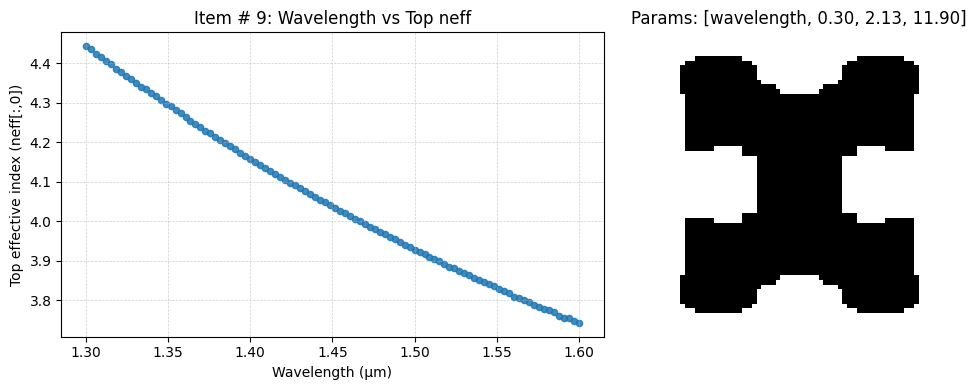

In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(file_path, "r") as f:
    params = f["params"][:]   # shape (N, 4)
    neff   = f["neff"][:]     # shape (N, M) where M >= 1 (top neff is [:,0])
    pattern = f["pattern"][:] # shape (N, H, W) or similar
    weight = f["weight"][:]

# Your dataset structure: 10 items, each with 100 points, in contiguous blocks.
POINTS_PER_ITEM = 100
num_items = params.shape[0] // POINTS_PER_ITEM  # should be 10

for i in range(num_items):
    start = i * POINTS_PER_ITEM
    end   = start + POINTS_PER_ITEM

    # X and Y for the scatter
    wavelengths = params[start:end, 0]   # Column 0: wavelength (µm)
    top_neff    = neff[start:end, 0]     # First (top) effective index

    # Representative waveguide pattern for the item (first point in block)
    pattern_img = pattern[start]

    # Create the figure with two panels
    fig, axes = plt.subplots(
        1, 2, figsize=(10, 4),
        gridspec_kw={"width_ratios": [3, 2]}
    )

    # Left: wavelength vs top neff
    ax = axes[0]
    ax.scatter(wavelengths, top_neff, s=20, alpha=0.85)
    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylabel("Top effective index (neff[:,0])")
    ax.set_title(f"Item # {i}: Wavelength vs Top neff")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    # Right: waveguide pattern image
    ax_img = axes[1]
    im = ax_img.imshow(pattern_img, origin="upper", cmap="Greys")
    ax_img.set_title(f"Params: [wavelength, {params[i][1]:.2f}, {params[i][2]:.2f}, {params[i][3]:.2f}]")
    ax_img.axis("off")

    plt.tight_layout()
    plt.show()


### Loading Cnn, plotting CNN values

In [17]:
# CNN takes (waveguide[:32, :32], params)
class CombinedModeWeightNet(nn.Module):
    def __init__(self, mode_model, weight_model):
        super().__init__()
        self.mode_model = mode_model
        self.weight_model = weight_model

    def forward(self, x_img, x_cond):
        mode = self.mode_model(x_img, x_cond)   # [B, 1]
        weight = self.weight_model(x_img, x_cond)  # [B, 1]
        return torch.cat((mode, weight), dim=1)   # [B, 2]

from only_mode_only_weight_v3 import No_normal_modewieght_net

device = 'cuda' if torch.cuda.is_available() else 'cpu'

mode0_model = No_normal_modewieght_net().to(device)
weight0_model = No_normal_modewieght_net().to(device)

mode0_model.load_state_dict(torch.load('models/models/only_first_mode_no_normalization_with_less_dropout.pth', map_location=torch.device(device)))
weight0_model.load_state_dict(torch.load('models/models/only_first_weight_no_normalization_with_less_dropout_100.pth', map_location=torch.device(device)))

cnn = CombinedModeWeightNet(mode0_model, weight0_model).to(device)
cnn.eval()

CombinedModeWeightNet(
  (mode_model): No_normal_modewieght_net(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn3): GroupNorm(8, 256, eps=1e-05, affine=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv4): Conv2d(260, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn4): GroupNorm(8, 256, eps=1e-05, affine=True)
    (conv5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn5): GroupNorm(8, 256, eps=1e-05, affine=True)
    (conv6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn6): GroupNorm(8, 256, eps=1e-05, affine=True)
    (conv7): Conv2d(256, 256, kernel_size=(3, 3),

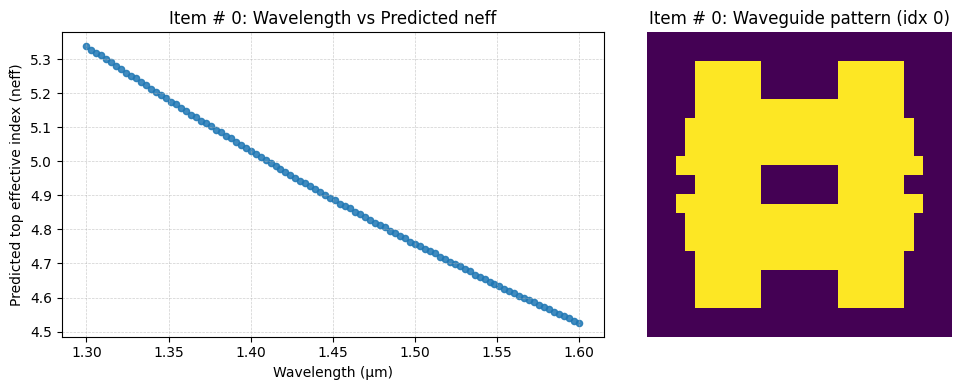

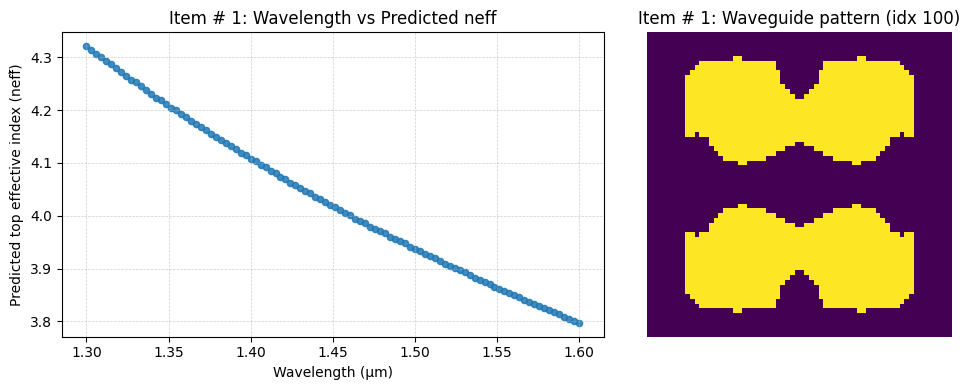

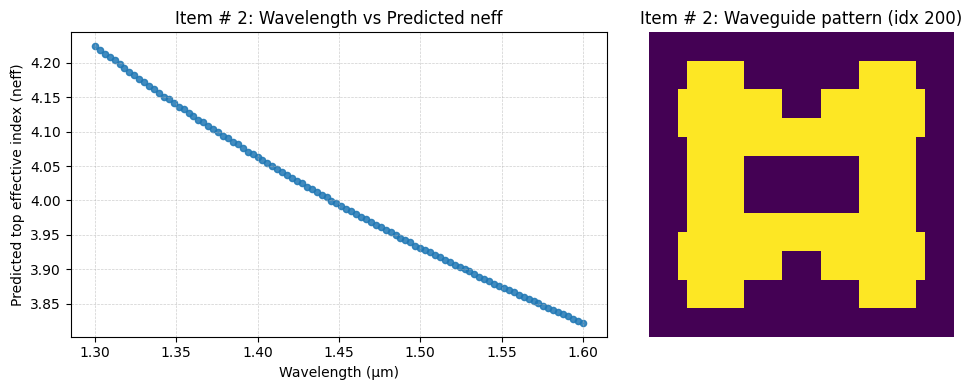

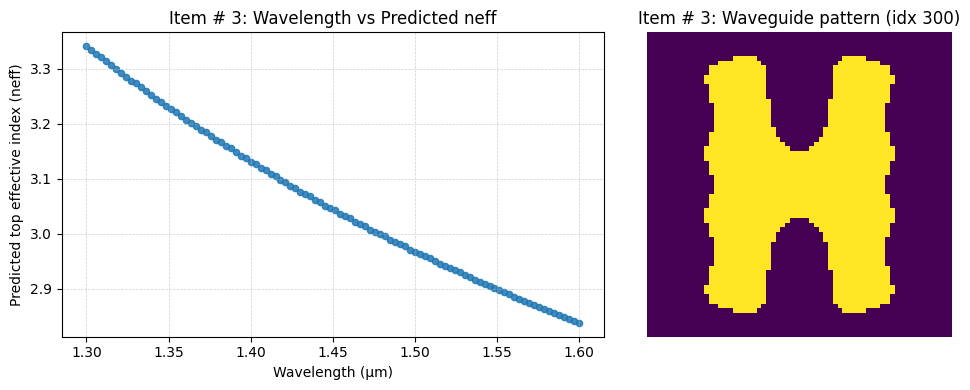

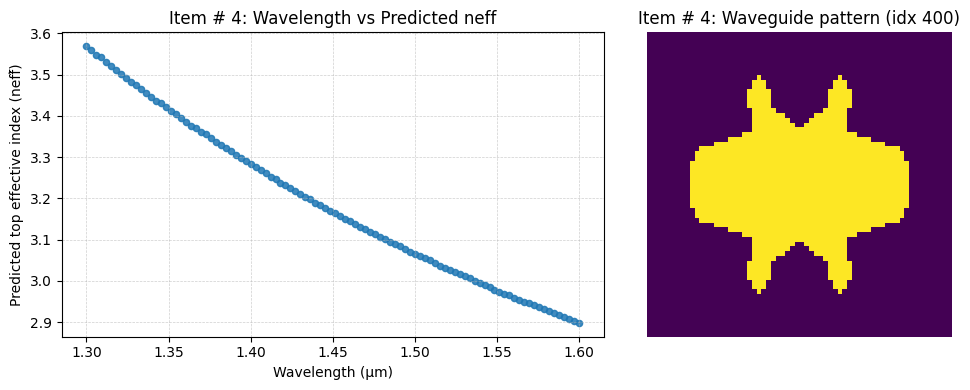

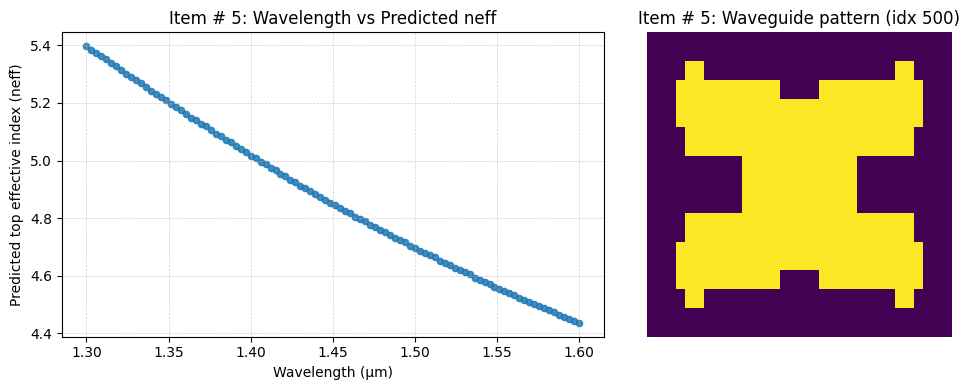

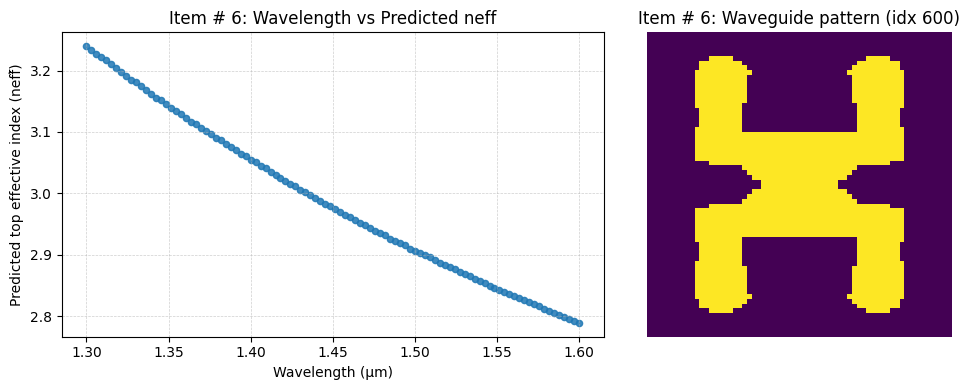

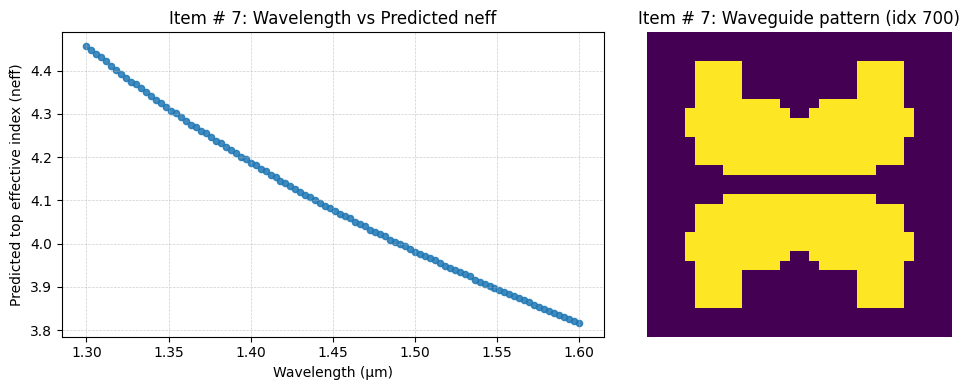

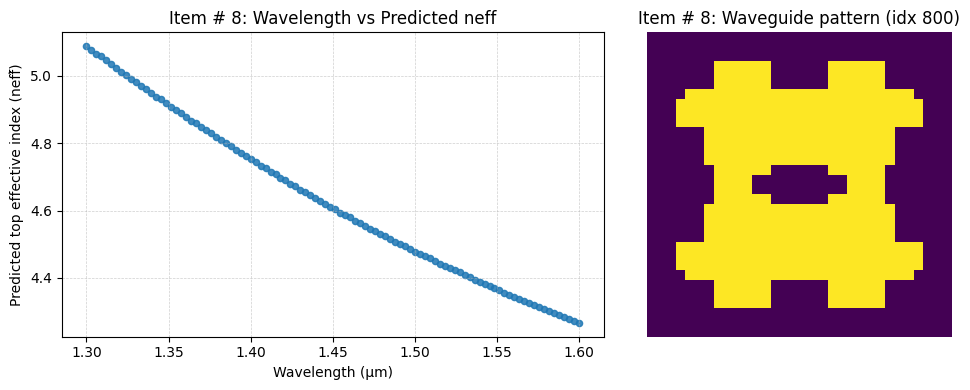

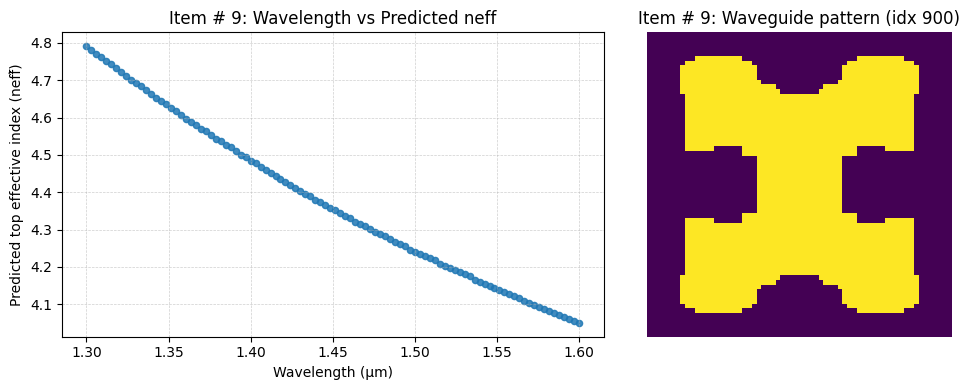

In [18]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch

FILE = "CollectData_expanded2.h5"
POINTS_PER_ITEM = 100

# Device + eval mode for your already-loaded model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn = cnn.to(device).eval()  # assumes cnn is already constructed/loaded

# --- Load data ---
with h5py.File(FILE, "r") as f:
    params  = f["params"][:]    # (N, 4): [wavelength, pitch_ratio, eps_sub, eps_atom]
    pattern = f["pattern"][:]   # (N, H, W)

num_items = params.shape[0] // POINTS_PER_ITEM  # should be 10

# --- Preprocess (adjust to match your training normalization if needed) ---
def preprocess_wg(x_np):
    x_np = x_np[:32, :32]                 # crop to 32x32 as requested
    x = torch.from_numpy(x_np).float()    # (32, 32)
    # If you normalized during training, do the same here.
    # x = (x - mean) / std
    x = x.unsqueeze(0).unsqueeze(0)       # (1, 1, 32, 32)
    return x

def preprocess_params(p_np):
    p = torch.from_numpy(p_np).float()    # (K, 4)
    # Apply any training-time normalization here if used.
    return p

@torch.no_grad()
def predict_neff_for_block(wg_img_np, params_block_np):
    """
    wg_img_np: (H, W) numpy array, same for the block
    params_block_np: (K, 4) numpy array, e.g. K=100
    Returns: (K,) numpy array of predicted top neff
    """
    wg_single = preprocess_wg(wg_img_np).to(device)         # (1,1,32,32)
    params_block = preprocess_params(params_block_np).to(device)  # (K,4)
    K = params_block.shape[0]

    # Repeat waveguide K times to match params
    wg_batch = wg_single.repeat(K, 1, 1, 1)                 # (K,1,32,32)

    # Forward: cnn returns (K, 2) = [neff, weight]
    out = cnn(wg_batch, params_block)                       # (K, 2)
    if out.ndim != 2 or out.size(-1) < 1:
        raise ValueError(f"Unexpected cnn output shape: {tuple(out.shape)}")

    neff_top = out[:, 0].detach().cpu().numpy()             # (K,)
    return neff_top

# --- Plotting loop: 10 figures (two panels each) ---
for i in range(num_items):
    start = i * POINTS_PER_ITEM
    end   = start + POINTS_PER_ITEM

    wavelengths  = params[start:end, 0]           # (100,)
    params_block = params[start:end, :]           # (100, 4)
    wg_img       = pattern[start]                 # representative waveguide for the item

    # Predict top neff from cnn
    neff_top_pred = predict_neff_for_block(wg_img, params_block)  # (100,)

    # Figure with two panels
    fig, axes = plt.subplots(
        1, 2, figsize=(10, 4),
        gridspec_kw={"width_ratios": [3, 2]}
    )

    # Left: wavelength vs predicted top neff
    ax = axes[0]
    ax.scatter(wavelengths, neff_top_pred, s=20, alpha=0.85)
    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylabel("Predicted top effective index (neff̂)")
    ax.set_title(f"Item # {i}: Wavelength vs Predicted neff")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    # Right: waveguide pattern
    ax_img = axes[1]
    ax_img.imshow(wg_img, origin="upper", cmap="viridis")
    ax_img.set_title(f"Item # {i}: Waveguide pattern (idx {start})")
    ax_img.axis("off")

    plt.tight_layout()
    plt.show()


### Plotting CNN values against Simulation Values

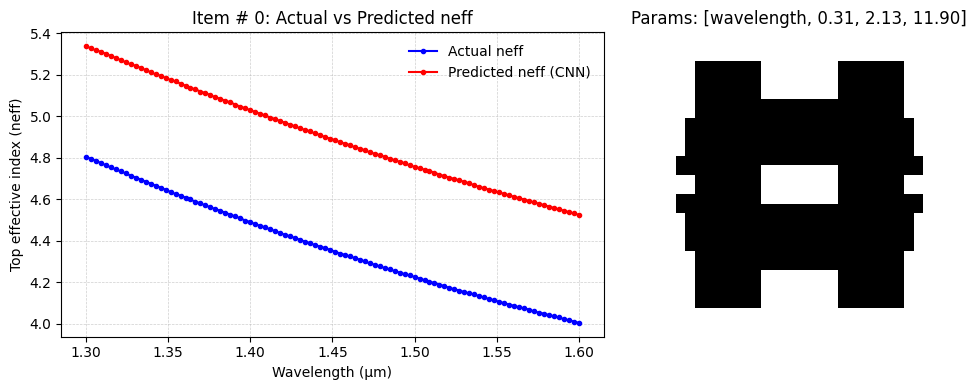

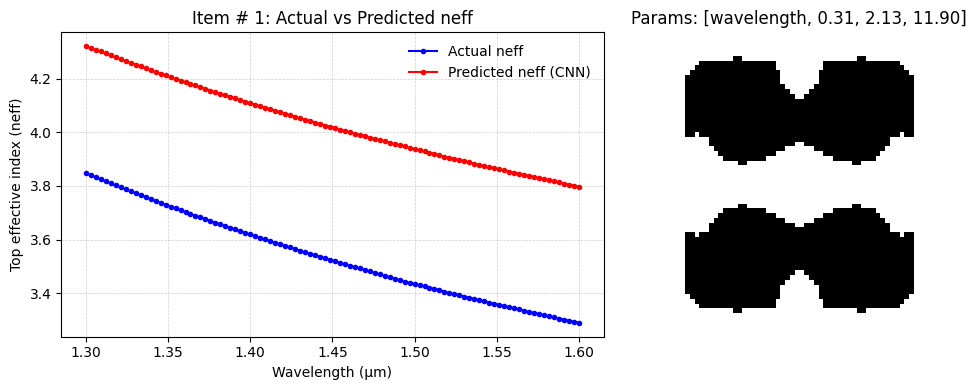

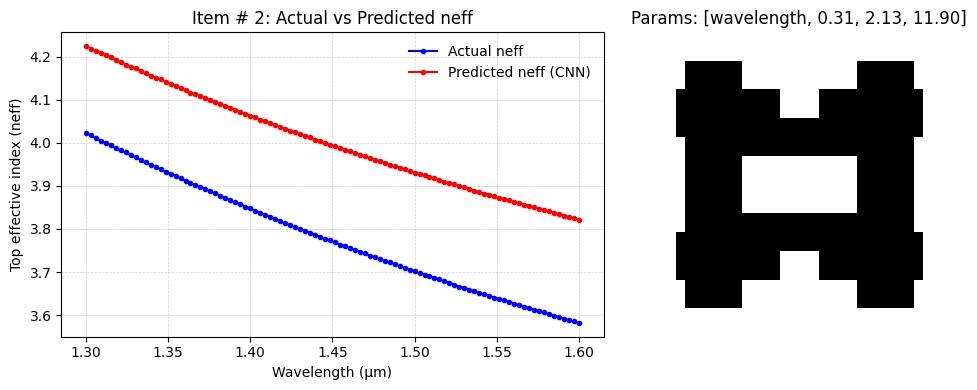

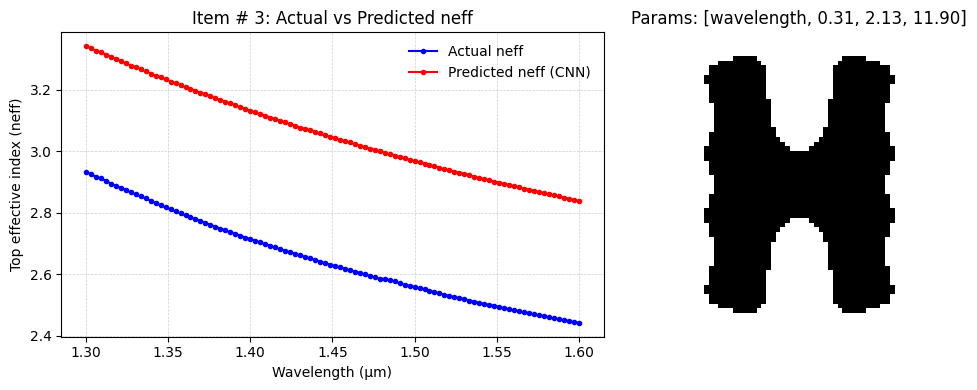

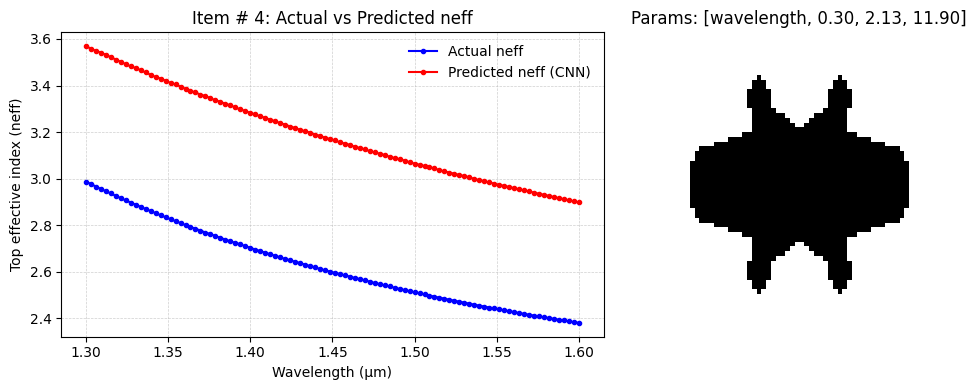

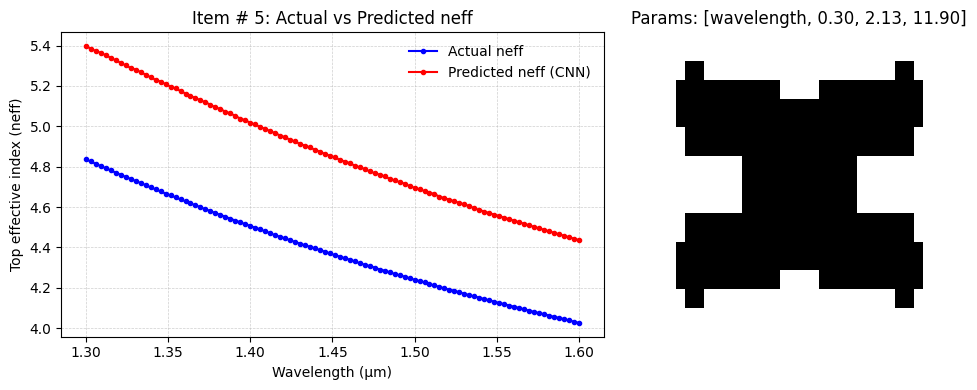

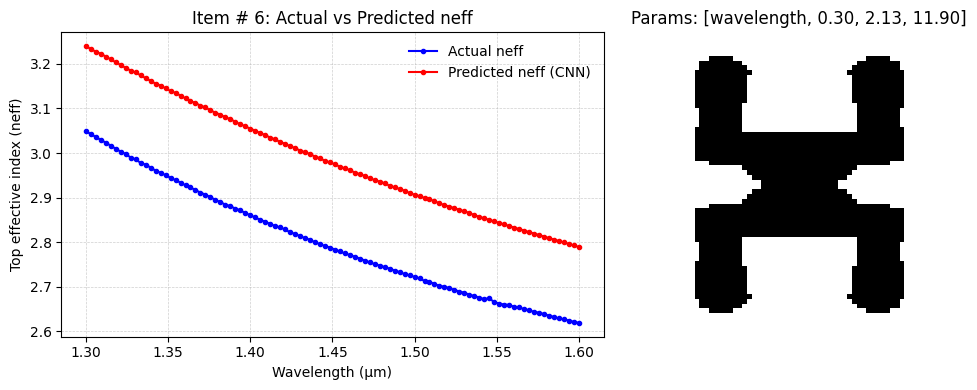

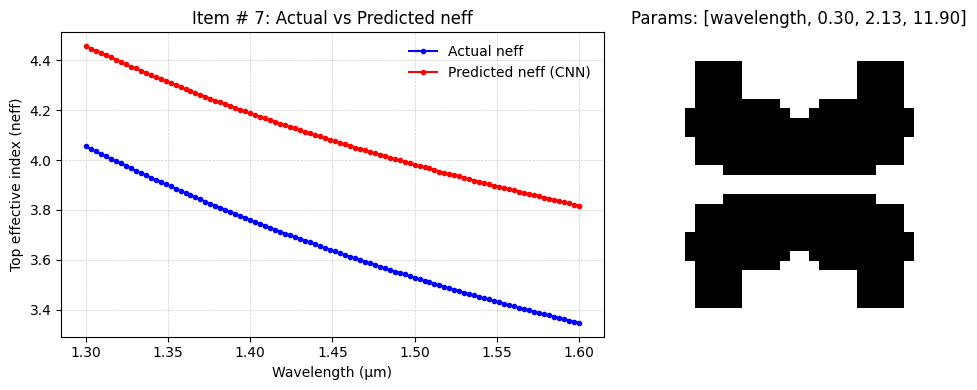

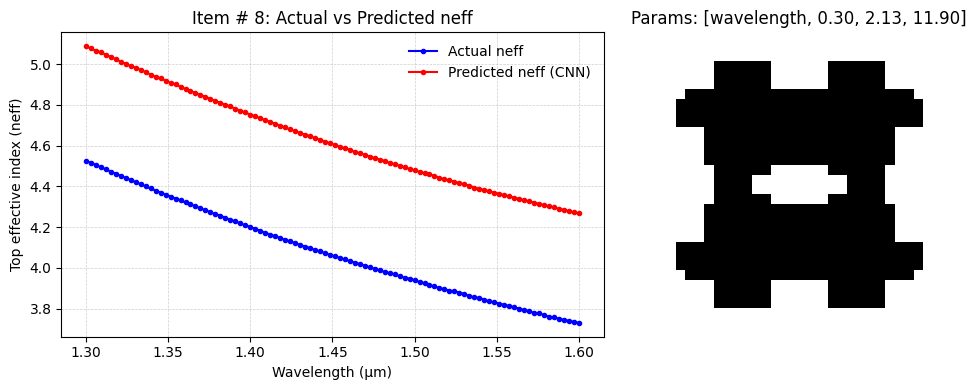

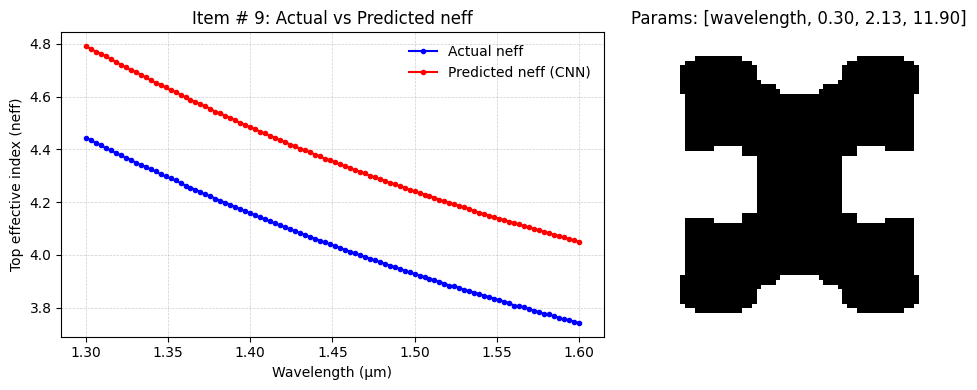

In [20]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch

FILE = "CollectData_expanded2.h5"
POINTS_PER_ITEM = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn = cnn.to(device).eval()

# --- Load data ---
with h5py.File(FILE, "r") as f:
    params  = f["params"][:]    # (N, 4): [wavelength, pitch_ratio, eps_sub, eps_atom]
    neff    = f["neff"][:]      # (N, M): top neff is [:,0]
    pattern = f["pattern"][:]   # (N, H, W)

num_items = params.shape[0] // POINTS_PER_ITEM  # should be 10

# --- Preprocessing (match training normalization if used) ---
def preprocess_wg(x_np):
    x_np = x_np[:32, :32]
    x = torch.from_numpy(x_np).float().unsqueeze(0).unsqueeze(0)
    return x

def preprocess_params(p_np):
    return torch.from_numpy(p_np).float()

@torch.no_grad()
def predict_neff_for_block(wg_img_np, params_block_np):
    wg_single = preprocess_wg(wg_img_np).to(device)
    params_block = preprocess_params(params_block_np).to(device)
    K = params_block.shape[0]
    wg_batch = wg_single.repeat(K, 1, 1, 1)
    out = cnn(wg_batch, params_block)            # (K, 2)
    neff_pred = out[:, 0].detach().cpu().numpy()
    return neff_pred

# --- Plotting loop: 10 figures ---
for i in range(num_items):
    start = i * POINTS_PER_ITEM
    end   = start + POINTS_PER_ITEM

    wavelengths  = params[start:end, 0]
    params_block = params[start:end, :]
    wg_img       = pattern[start]

    # CNN predictions
    neff_pred = predict_neff_for_block(wg_img, params_block)
    # Actual top neff from dataset
    neff_actual = neff[start:end, 0]

    # Figure with two panels
    fig, axes = plt.subplots(
        1, 2, figsize=(10, 4),
        gridspec_kw={"width_ratios": [3, 2]}
    )

    # Left: wavelength vs neff (actual vs predicted)
    ax = axes[0]
    ax.plot(wavelengths, neff_actual, 'o-', color='blue', label='Actual neff', markersize=3)
    ax.plot(wavelengths, neff_pred, 'o-', color='red', label='Predicted neff (CNN)', markersize=3)
    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylabel("Top effective index (neff)")
    ax.set_title(f"Item # {i}: Actual vs Predicted neff")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax.legend(frameon=False)

    # Right: waveguide pattern
    ax_img = axes[1]
    ax_img.imshow(wg_img, origin="upper", cmap="Greys")
    ax_img.set_title(f"Params: [wavelength, {params[i][1]:.2f}, {params[i][2]:.2f}, {params[i][3]:.2f}]")
    ax_img.axis("off")

    plt.tight_layout()
    plt.show()
